# A2 : Language Model

In [2]:
# imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from nltk.corpus import gutenberg
import nltk
import math
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:1


## Download the dataset and tokenize 

For A2 I have planned to use "Bible" as the dataset. Using prebuilt King James Version (kjv) from nltk library.

In [4]:
nltk.download('gutenberg')

#load and tokenize
bible_text = gutenberg.raw('bible-kjv.txt').lower()
tokenizer = get_tokenizer('basic_english')
tokens = tokenizer(bible_text)

#build vocab
def yield_tokens():
    yield tokens

vocab = build_vocab_from_iterator(yield_tokens(), specials=['<unk>', '<pad>', '<eos>'])
vocab.set_default_index(vocab['<unk>'])
vocab_size = len(vocab)
print(vocab_size)


[nltk_data] Downloading package gutenberg to /home/jupyter-
[nltk_data]     st124371/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


12765


# Prepare the batch loader

In [5]:
# Convert all tokens to numerical indices
data_indices = torch.LongTensor(vocab(tokens))

# Doing a 80-10-10 split here
def split_data(data, train_p=0.8, val_p=0.1):
    n = len(data)
    train_data = data[:int(n * train_p)]
    val_data = data[int(n * train_p):int(n * (train_p + val_p))]
    test_data = data[int(n * (train_p + val_p)):]
    return train_data, val_data, test_data

train_raw, val_raw, test_raw = split_data(data_indices)
print(train_raw)

tensor([8807,   58, 1358,  ...,   35,   13,   24])


In [6]:
#fn to divide dataset to batch
# narrow(dimension,start,length) -> creates a window into a specific part of the tensor ensuring dataset length is exactly divisible by the batch_size
def batchify(data, batch_size):
    nbatch = data.size(0) // batch_size
    data = data.narrow(0, 0, nbatch * batch_size)
    data = data.view(batch_size, -1).t().contiguous()
    return data.to(device)

In [7]:
BATCH_SIZE = 64
train_data = batchify(train_raw, BATCH_SIZE)
val_data = batchify(val_raw, BATCH_SIZE)
test_data = batchify(test_raw, BATCH_SIZE)

def get_batch(source, i, seq_len):
    seq_len = min(seq_len, len(source) - 1 - i)
    data = source[i:i+seq_len].t()
    target = source[i+1:i+1+seq_len].t().reshape(-1)
    return data, target

In [8]:
print(train_data)

tensor([[8807,  110,   17,  ...,   26,  493,   20],
        [  58,   36, 1346,  ...,  524,  102, 1093],
        [1358,   33,    3,  ...,    3,  351,   26],
        ...,
        [ 600,   25,  397,  ...,    3, 1006,   41],
        [   7,   61,    3,  ...,   43,    3,    7],
        [ 105,   14,    5,  ...,  146,    5,   53]], device='cuda:1')


# Modelling
I was experimenting with a bunch of things here and thought to experiment with two different models to see how the output would be any different. <br>

1. BasicLSTM - This is a vanilla RNN setup where we process tokens one by one maintaining the hidden state that acts as a bottleneck for all previous information. The basic flow is Embedding -> LSTM Layers -> Fully Connected Layers.
2. ImprovedAttentionLSTM - This model uses LSTM as a feature extractor and applies "Causal Self Attention" mechanism to allow every token to 'look back' at all previous tokens simultaneously. First, I tried without the causal mask and realised that the model was cheating during training by looking at future token. Since, this is the attention version, it is important to mask, else the matmul(Q,K.T) would allow information to flow backward from future time steps. In baseline model we did not have this issue because of the sequential nature of RNN. Also, this model has a LayerNorm which is basically normalizing the hidden states to prevent exploding or vanishing gradients (for smoother training).


In [9]:
# Model 1 - Baseline
class BasicLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        embedded = self.embedding(x)
        out, _ = self.lstm(embedded)
        return self.fc(out)


In [10]:
# Model 2
class ImprovedAttentionLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        
        #LayerNorm for stability
        self.layer_norm = nn.LayerNorm(hidden_dim)
        
        self.lin_Q = nn.Linear(hidden_dim, hidden_dim)
        self.lin_K = nn.Linear(hidden_dim, hidden_dim)
        self.lin_V = nn.Linear(hidden_dim, hidden_dim)
        
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def self_attention(self, x):
        #Normalize the LSTM output
        x = self.layer_norm(x)
        
        Q, K, V = self.lin_Q(x), self.lin_K(x), self.lin_V(x)
        d_k = K.size(-1)
        
        #scaled dot product
        scores = torch.matmul(Q, K.transpose(1, 2)) / math.sqrt(d_k)
        
        #causal mask
        mask = torch.triu(torch.ones(scores.size(-1), scores.size(-1), device=device), diagonal=1).bool()
        scores.masked_fill_(mask, -1e9)
        
        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(self.dropout(attn), V)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        context = self.self_attention(out)
        return self.fc(context)

# Training

Following things were considered during training:

- Since, I had two models and I did not want to have two training loops, a new function <b>train_engine</b> is implemented. This allows me to pass whatever model, I want to experiment with. This was done because I was playing with a few models from the Appendix. I finally settled for the ImprovedSelfAttention and the baseline.
- Stores all train and val loss for visualization and model comparison
- Early stopping mechanism is added - Since I am doing this in puffer, I wanted the training to stop automatically even if I pass a large epoch value.
- Each model with the best score is always saved. This will be used in the application later.
- Ppl (Perplexity) - Since, I am comparing two models, simplying comparing two losses would not be ideal. Taking the exponential of the loss would allow a little interpretability, thus I added it to understand which model is doing better. 
  


In [11]:
def evaluate(model, data_source, criterion, seq_len):
    model.eval()
    total_loss = 0.
    with torch.no_grad():
        for i in range(0, data_source.size(0) - 1, seq_len):
            data, targets = get_batch(data_source, i, seq_len)
            output = model(data)
            total_loss += len(data) * criterion(output.view(-1, vocab_size), targets).item()
    return total_loss / (len(data_source) - 1)

def train_engine(model, train_data, val_data, epochs, seq_len, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.5)
    
    best_val_loss = float('inf')
    patience = 3
    counter = 0
    history = {'train': [], 'val': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.
        for i in range(0, train_data.size(0) - 1, seq_len):
            data, targets = get_batch(train_data, i, seq_len)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output.view(-1, vocab_size), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            total_loss += loss.item()

        val_loss = evaluate(model, val_data, criterion, seq_len)
        avg_train_loss = total_loss / (train_data.size(0) // seq_len)
        history['train'].append(avg_train_loss)
        history['val'].append(val_loss)
        
        scheduler.step(val_loss)
        print(f'| Epoch {epoch+1:02d} | Train Loss {avg_train_loss:.3f} | Val Loss {val_loss:.3f} | Ppl {math.exp(val_loss):.2f}')

        # early stop and checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    return history

In [12]:
#hyperparameters
EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.4
SEQ_LEN = 40
EPOCHS = 50 

#run exp1
basic_model = BasicLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
basic_hist = train_engine(basic_model, train_data, val_data, EPOCHS, SEQ_LEN, "basic_lstm")

| Epoch 01 | Train Loss 5.845 | Val Loss 8.996 | Ppl 8071.06
| Epoch 02 | Train Loss 4.870 | Val Loss 8.163 | Ppl 3507.95
| Epoch 03 | Train Loss 4.494 | Val Loss 7.816 | Ppl 2479.06
| Epoch 04 | Train Loss 4.264 | Val Loss 7.601 | Ppl 2000.12
| Epoch 05 | Train Loss 4.092 | Val Loss 7.500 | Ppl 1808.54
| Epoch 06 | Train Loss 3.958 | Val Loss 7.437 | Ppl 1698.38
| Epoch 07 | Train Loss 3.845 | Val Loss 7.394 | Ppl 1626.79
| Epoch 08 | Train Loss 3.743 | Val Loss 7.359 | Ppl 1569.79
| Epoch 09 | Train Loss 3.652 | Val Loss 7.348 | Ppl 1553.19
| Epoch 10 | Train Loss 3.570 | Val Loss 7.343 | Ppl 1545.56
| Epoch 11 | Train Loss 3.493 | Val Loss 7.333 | Ppl 1530.19
| Epoch 12 | Train Loss 3.423 | Val Loss 7.340 | Ppl 1540.27
| Epoch 13 | Train Loss 3.358 | Val Loss 7.346 | Ppl 1549.50
| Epoch 14 | Train Loss 3.285 | Val Loss 7.326 | Ppl 1519.76
| Epoch 15 | Train Loss 3.244 | Val Loss 7.334 | Ppl 1531.91
| Epoch 16 | Train Loss 3.207 | Val Loss 7.343 | Ppl 1545.02
| Epoch 17 | Train Loss 

In [13]:
#hyperparameters
EMBED_DIM = 256
HIDDEN_DIM = 256 # small hidden dim helps prevent overfitting 
NUM_LAYERS = 2
DROPOUT = 0.3     
SEQ_LEN = 60  # longer sequences are favored for attention over the baseline   
EPOCHS = 50     

#run exp2
attn_model = ImprovedAttentionLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
attn_hist = train_engine(attn_model, train_data, val_data, EPOCHS, SEQ_LEN, "attn_lstm")

| Epoch 01 | Train Loss 5.788 | Val Loss 5.501 | Ppl 245.00
| Epoch 02 | Train Loss 4.827 | Val Loss 5.157 | Ppl 173.64
| Epoch 03 | Train Loss 4.522 | Val Loss 5.026 | Ppl 152.27
| Epoch 04 | Train Loss 4.342 | Val Loss 4.960 | Ppl 142.66
| Epoch 05 | Train Loss 4.205 | Val Loss 4.914 | Ppl 136.16
| Epoch 06 | Train Loss 4.088 | Val Loss 4.884 | Ppl 132.21
| Epoch 07 | Train Loss 3.993 | Val Loss 4.866 | Ppl 129.78
| Epoch 08 | Train Loss 3.909 | Val Loss 4.851 | Ppl 127.88
| Epoch 09 | Train Loss 3.835 | Val Loss 4.862 | Ppl 129.28
| Epoch 10 | Train Loss 3.766 | Val Loss 4.872 | Ppl 130.55
| Epoch 11 | Train Loss 3.653 | Val Loss 4.849 | Ppl 127.59
| Epoch 12 | Train Loss 3.598 | Val Loss 4.869 | Ppl 130.23
| Epoch 13 | Train Loss 3.555 | Val Loss 4.881 | Ppl 131.80
| Epoch 14 | Train Loss 3.497 | Val Loss 4.904 | Ppl 134.80
Early stopping triggered.


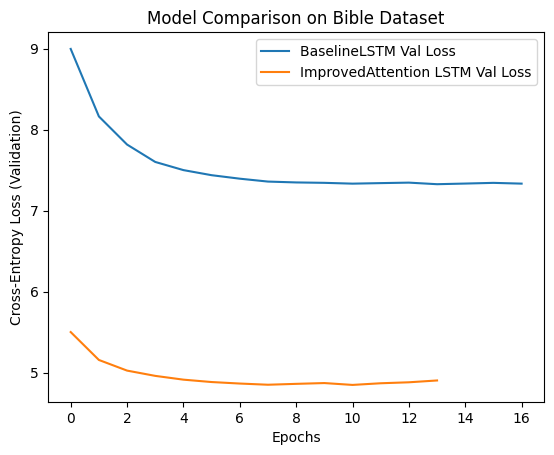

In [18]:
#viz
plt.plot(basic_hist['val'], label='BaselineLSTM Val Loss')
plt.plot(attn_hist['val'], label='ImprovedAttention LSTM Val Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss (Validation)')
plt.title("Model Comparison on Bible Dataset")
plt.show()

# Interpretting and understanding the results

1. PPL - The difference in validation perplexity (ppl) is huge. The baseline achieves a best of 1519 while the attention model achieves a best of 127. This generally means that my attention model is about 10x more certain about its predictions than the baseline.
2. Why did Attention outperform ? - <b>Reason 1</b> Since the attention can look back at all previous words it can shortcut the distance between say, a subject at the start and a verb at the end. While the baseline is processing infromation like say a person reading a book one word at a time (where the person forgets the beginning of the sentence by the time it reaches the end). <b>Reason 2</b> - LayerNorm was added to improve training stability for Attention model. We can notice that the training loss starts lower than the baseline and the distance between the two losses is close too.
3. Overfitting - The baseline is severely overfitting. Although the attention is also overfitting but the gap between the two loss (train and val) is relatively low (gap of loss for baseline = 4.1 and gap of loss for Attention = 1.4).
4. The early stopping came handy here. We did not have to train for a crazy amount of time. 

# Inference

In [15]:
def generate_text(model_path, model_class, prompt, config, max_words=50):
    # Since I am using different hyperparams, I need to re initialize with the same config
    model = model_class(
        vocab_size, 
        config['embed_dim'], 
        config['hidden_dim'], 
        config['num_layers'], 
        config['dropout']
    ).to(device)
    
    #load the weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    words = tokenizer(prompt)
    indices = [vocab[w] for w in words]
    
    for _ in range(max_words):
        input_tensor = torch.LongTensor([indices]).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            probs = F.softmax(output[0, -1, :] / 0.85, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()
            indices.append(next_idx)
            if next_idx == vocab['<eos>']: break
            
    return ' '.join(vocab.lookup_tokens(indices))

In [17]:
# config1 - Baseline
basic_config = {
    'embed_dim': 256,
    'hidden_dim': 512,
    'num_layers': 2,
    'dropout': 0.4
}

# config2 - ImprovedAttention
attn_config = {
    'embed_dim': 256,
    'hidden_dim': 256, 
    'num_layers': 2,
    'dropout': 0.3
}

test_prompt = "Lord is my"

print("Basic LSTM Generation:")
print(generate_text('best_basic_lstm.pt', BasicLSTM, test_prompt, basic_config))

print("\nAttention LSTM Generation:")
print(generate_text('best_attn_lstm.pt', ImprovedAttentionLSTM, test_prompt, attn_config))

Basic LSTM Generation:
lord is my strength to the house of my lord a man , and thou art my son , that thou shalt not be able to bring forth to cause the thing visiting the lord his god that is in heaven . 37 32 and i believed him not . 1 31 and

Attention LSTM Generation:
lord is my beloved . 1 56 therefore my beloved are girded with my darling , and me in my lips . 1 132 that let my voice please my spirit in the midst of mine people through my eyes , and my breasts have pity . 2 7 my beloved roareth rebuked


# Interpreting the real inference output

Although the loss has been interpreted above. Comparing the inference output is crucial too. Here is my analysis of the output:

- The Baseline model is produciing 'word salad'. There is very less logical meaning (eg 'not be able to bring forth to cause the thing'). While, the Attention is generating semantically linked thoughts (eg 'let my voice please my spirit')
- The Attention model is more thematic consistent and uses consistent vocab like beloved, darling and spirit. The Baseline flips randomly between unrelated concepts like 'house of my lord' , 'visiting the lord' , 'heaven'. It fails to stick to a single narative theme.
- The Baseline is treating numbers are random noise and is displaying them randomly across the text specially in the middle of the sentence (eg, heaven . 37 32) while the Attention model is using numbers as logical anchords for verse markers (eg 1 56 , 2 7)


In [19]:
#saving vocab for app
import pickle
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)